In [1]:
# importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
from collections import Counter
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import Datasets

In [2]:
# reading the datasets

df_cat = pd.read_csv('data/category_tree.csv')
df_event = pd.read_csv('data/events.csv')
df_item_prop_1 = pd.read_csv('data/item_properties_part1.csv')
df_item_prop_2 = pd.read_csv('data/item_properties_part2.csv')

In [3]:
# combining the both item prop dfs
df_item_prop = pd.concat([df_item_prop_1, df_item_prop_2], ignore_index=True)

In [4]:
del df_item_prop_1, df_item_prop_2

print(df_cat.shape, df_event.shape, df_item_prop.shape)

(1669, 2) (2756101, 5) (20275902, 4)


### Basic stats of data & preprocessing

#### Category map data

In [5]:
# basic stats

df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [6]:
# understanding what the table contains

df_cat.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [7]:
# Checking for Nulls and Duplicates  - we replace the nulls with the category id itself

print(df_cat.isna().sum())
print(df_cat.duplicated().sum())

categoryid     0
parentid      25
dtype: int64
0


In [8]:

# pure parent - categories who don't have parents but are parents of other categories - 24
# all 362 parents exist in category id, but 24 of them dont have any parent, 
# but there is 1 category id, which is no ones parent and doesnt have a parent as well

cat_parent_null = df_cat.loc[df_cat.parentid.isnull(), 'categoryid'].unique()
all_parents = df_cat.loc[df_cat.parentid.notnull(),'parentid'].unique()
all_cats = df_cat['categoryid'].unique()

print("parents that are also categories: ", np.isin(all_parents, all_cats).sum())
print("Pure parent no. : ", np.isin(cat_parent_null, all_parents).sum())
print("the category which doesnt have any parent nor is parent of anuyone: ", [cat_id for cat_id in cat_parent_null if cat_id not in all_parents])


parents that are also categories:  362
Pure parent no. :  24
the category which doesnt have any parent nor is parent of anuyone:  [np.int64(231)]


In [9]:
# setting the parent to cat_id itself wherever nulls

df_cat = duckdb.query("select categoryid, coalesce(parentid, categoryid) as parentid from df_cat").to_df()

#### Event data

In [10]:
df_event.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


In [11]:
# change the timestamp - check for duplicates, cant remove the NaNs in TID - because it corresponds to view/atc

df_event.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [12]:
# 460 duplicate entries - no reason for duplicates, should remove them

print(df_event.isna().sum())
print(df_event.duplicated().sum())


df_event.drop_duplicates(inplace=True)

print(df_event.duplicated().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64
460
0


#### Item Property

In [13]:
#  logs form of data, contains the entry whenever anything is updated 

df_item_prop.info()

<class 'pandas.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   timestamp  int64
 1   itemid     int64
 2   property   str  
 3   value      str  
dtypes: int64(2), str(2)
memory usage: 618.8 MB


In [14]:
# change timestamp

df_item_prop.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [15]:
# no duplicates - no nulls

print(df_item_prop.isna().sum())
print(df_item_prop.duplicated().sum())

timestamp    0
itemid       0
property     0
value        0
dtype: int64
0


In [16]:
# update the timestamp to datetime value in both df_event and df_item_prop

df_event['timestamp'] = pd.to_datetime(df_event['timestamp'], unit='ms').dt.strftime('%Y-%m-%d %H:%M:%S')
df_item_prop['timestamp'] = pd.to_datetime(df_item_prop['timestamp'], unit='ms').dt.strftime('%Y-%m-%d %H:%M:%S')

In [ ]:
# creating a transaction df, which can be used laters to get orders

transactions_df = (
    df_event[df_event.transactionid.notnull()]
    .sort_values('timestamp')
)

### Basic EDA

In [18]:
# total unique items - this includes the 1 category in parent which was not earlier present 362 - 363
df_cat.nunique()

categoryid    1669
parentid       363
dtype: int64

In [19]:
df_event[['visitorid', 'itemid', 'event', 'transactionid']].nunique()

visitorid        1407580
itemid            235061
event                  3
transactionid      17672
dtype: int64

In [20]:
# looking at the 3 unique events
df_event.event.unique()

<StringArray>
['view', 'addtocart', 'transaction']
Length: 3, dtype: str

In [21]:
df_item_prop.nunique() # property has values - categoryid, available (0/1), rest all are hashed

timestamp         18
itemid        417053
property        1104
value        1966868
dtype: int64

In [22]:
# count of events (event share) = 22457 orders only
df_event.groupby('event')['itemid'].count()

event
addtocart        68966
transaction      22457
view           2664218
Name: itemid, dtype: int64

In [23]:
# create an item category map dataframe - latest mapping 

item_cat_map = duckdb.query("select itemid, value as cat_id, row_number() over(partition by itemid, property order by timestamp desc) rn from df_item_prop where property ='categoryid'").to_df()

In [24]:
# this proves that our mapping table has mapping to every item

print("unique items in item properties: ", df_item_prop.loc[df_item_prop['property']=='categoryid','itemid'].nunique())
item_cat_map[item_cat_map['rn']==1].count()

unique items in item properties:  417053


itemid    417053
cat_id    417053
rn        417053
dtype: int64

In [25]:
# top 5 users

user_orders = df_event.loc[df_event['event']=='transaction',['event','visitorid']].groupby('visitorid').count().sort_values(by='event', ascending=False).reset_index()

user_orders.head()

,visitorid,event
0,1150086,559
1,152963,349
2,530559,286
3,684514,189
4,861299,188


In [26]:
# lets get the top 5 items bought
item_orders = df_event.loc[df_event['event']=='transaction',['event','itemid']].groupby('itemid').count().sort_values(by='event', ascending=False).reset_index()

item_orders.head()

,itemid,event
0,461686,133
1,119736,97
2,213834,92
3,7943,46
4,312728,46


In [27]:
# top 5 categories

cat_orders = duckdb.query("select cat_id, sum(event) as orders from item_orders a left join item_cat_map b on a.itemid = b.itemid group by 1 order by 2 desc").to_df()

cat_orders.head()

,cat_id,orders
0,1509,2015.0
1,1613,1994.0
2,491,1528.0
3,1120,900.0
4,720,724.0


In [28]:
# 380 items presen in event dont have category mapped to them in item properties

duckdb.query("select count(*) as items from item_orders a left join item_cat_map b on a.itemid = b.itemid where b.itemid is null").to_df()

,items
0,380


In [29]:
# count of categories oc wise - only 7 categories contribute to over 20% of orders
cat_oc_q = """
select 
    case 
        when cum_oc < 0.1 then 'a.0to10'
        when cum_oc < 0.2 then 'b.10to20'
        when cum_oc < 0.3 then 'c.20to30'
        when cum_oc < 0.4 then 'd.30to40'
        when cum_oc < 0.5 then 'e.40to50'
        when cum_oc < 0.6 then 'f.50to60' 
        when cum_oc < 0.1 then 'g.60to70'
        when cum_oc < 0.1 then 'h.70to80'
        when cum_oc < 0.1 then 'i.80to90'
    else 'j.90to100' end as oc_decile,
    count(cat_id) as cat_count
from (
select 
    *,
    sum(orders) over(order by orders desc rows between unbounded preceding and current row)*1.0000/sum(orders) over() as cum_oc,
    sum(orders) over(order by orders desc rows between unbounded preceding and current row) as cum_orders, 
    sum(orders) over() as total_orders
from 
    cat_orders
)
group by 1
order by 1
"""

duckdb.query(cat_oc_q).to_df()

,oc_decile,cat_count
0,a.0to10,2
1,b.10to20,5
2,c.20to30,8
3,d.30to40,13
4,e.40to50,19
5,f.50to60,29
6,j.90to100,675


In [30]:
# count of items oc wise - 435 items contribute to over 20% of orders
item_oc_q = """
select 
    case 
        when cum_oc < 0.1 then 'a.0to10'
        when cum_oc < 0.2 then 'b.10to20'
        when cum_oc < 0.3 then 'c.20to30'
        when cum_oc < 0.4 then 'd.30to40'
        when cum_oc < 0.5 then 'e.40to50'
        when cum_oc < 0.6 then 'f.50to60' 
        when cum_oc < 0.1 then 'g.60to70'
        when cum_oc < 0.1 then 'h.70to80'
        when cum_oc < 0.1 then 'i.80to90'
    else 'j.90to100' end as oc_decile,
    count(itemid) as cat_count
from (
select 
    *,
    sum(event) over(order by event desc rows between unbounded preceding and current row)*1.0000/sum(event) over() as cum_oc,
    sum(event) over(order by event desc rows between unbounded preceding and current row) as cum_orders, 
    sum(event) over() as total_orders
from 
    item_orders

)
group by 1
order by 1
"""

duckdb.query(item_oc_q).to_df()

,oc_decile,cat_count
0,a.0to10,118
1,b.10to20,317
2,c.20to30,504
3,d.30to40,694
4,e.40to50,920
5,f.50to60,1123
6,j.90to100,8349


In [31]:
# customer segmentation

ordered_users = df_event[df_event.event == 'transaction'].visitorid.unique()
atc_users = df_event[df_event.event == 'addtocart'].visitorid.unique()
viewed_users = df_event[df_event.event == 'view'].visitorid.unique()
all_users = df_event.visitorid.unique()
browsed_users = [u for u in all_users if u not in ordered_users] # users who only browsed bu didnt buy anything ever

print("num of ordered users: ", ordered_users.size)
print("num of atc users: ", atc_users.size)
print("num of viewed users: ", viewed_users.size)

print("num of all users: ", all_users.size)
print("num of all users who did not buy anything: ", len(browsed_users))


num of ordered users:  11719
num of atc users:  37722
num of viewed users:  1404179
num of all users:  1407580
num of all users who did not buy anything:  1395861


In [32]:
df_event.timestamp = pd.to_datetime(df_event.timestamp)

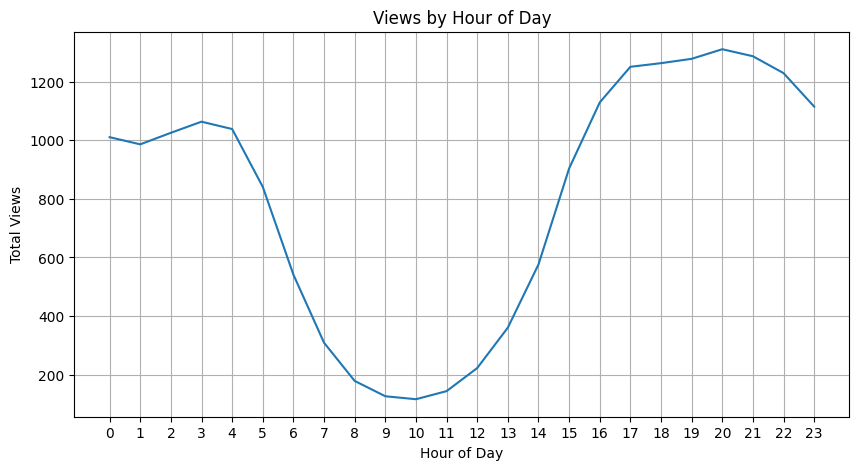

In [33]:
# importance of time of day - peak user activity between 5pm to 10pm and, 
# lowest activity between 8am to 11am - mostly because of timeszone change - should be very similar to meesho 

hoh_views = duckdb.query("""
select hour_of_day, avg(views) as avg_views
from (
select 
    date(timestamp) as date, hour(timestamp) as hour_of_day, count(*) as views
from 
    df_event
where 
    event = 'view'
group by 1,2
)
group by 1
order by 1
""").to_df()

plt.figure(figsize=(10,5))

plt.plot(hoh_views['hour_of_day'], hoh_views['avg_views'])

plt.xlabel('Hour of Day')
plt.ylabel('Total Views')
plt.title('Views by Hour of Day')

plt.xticks(range(24))   # optional: show all hours 0-23
plt.grid(True)

plt.show()


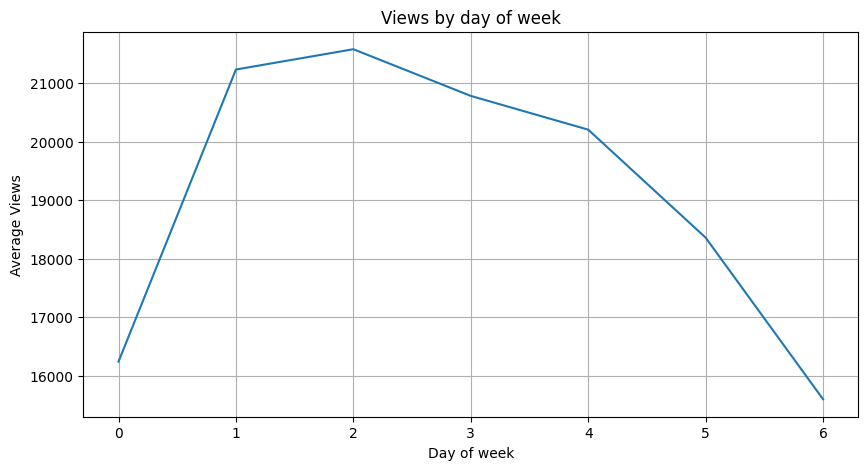

In [34]:
# importance of time of day - peak user activity on Monday and Tuesday (0 - sunday while 7 is saturday)

dow_views = duckdb.query("""
select day_of_week, avg(views) as avg_views
from (
select 
    date(timestamp) as date, dayofweek(timestamp) as day_of_week, count(*) as views
from 
    df_event
where 
    event = 'view'
group by 1,2
)
group by 1
order by 1
""").to_df()

plt.figure(figsize=(10,5))

plt.plot(dow_views['day_of_week'], dow_views['avg_views'])

plt.xlabel('Day of week')
plt.ylabel('Average Views')
plt.title('Views by day of week')

# plt.xticks(range(24))   # optional: show all hours 0-23
plt.grid(True)

plt.show()


### Basic recommender

In [35]:
transactions_df.tail()

,timestamp,visitorid,event,itemid,transactionid
1456656,2015-09-18 02:08:16,152963,transaction,380196,5772.0
1462450,2015-09-18 02:08:16,152963,transaction,334401,5772.0
1462449,2015-09-18 02:08:16,152963,transaction,122984,5772.0
1456772,2015-09-18 02:38:18,152963,transaction,362697,5670.0
1454084,2015-09-18 02:43:12,152963,transaction,21970,8904.0


In [36]:
# returns top n platform items

def popularity_reco(curr_timestamp, n):

    return transactions_df[transactions_df.timestamp < curr_timestamp].groupby('itemid').size().sort_values(ascending=False).index.tolist()[:n]

In [37]:
# this returns the orders of users till the given timestamp

def pre_purchased_list(curr_timestamp):

    return transactions_df[transactions_df.timestamp < curr_timestamp].groupby('visitorid')['itemid'].apply(list).tolist()


In [77]:
# Any time a user comes onto the platform, we check the user's last interaction of item, 
# and recommend products that other users bought who also bought the current user's last interacted item.
# if no user bought the last interacted item or if user is new and no prior data is available, we recommend top 10 platform popular item

def recommender_bought_bought(user_id, curr_timestamp, size):
    
    '''
    inputs - 
    user_id - user id for whom we are recommending
    curr_timestamp - curr timestamp of recommendation

    intermediate -
    prev_item_id - what was the last interacted item for the user till the curr timestamp 
    prev_purchased_items - what were the purchased products list till the curr timestamp

    output -
    recommender_list - array of recommended products
    '''

    already_purchased = set(transactions_df.loc[((transactions_df.visitorid ==  user_id) & (transactions_df.timestamp < curr_timestamp)), 'itemid'])

    n = 100
    popular_items = [item for item in popularity_reco(curr_timestamp, n) if item not in already_purchased] # returns n top items of platform

    pre_item_list = df_event.loc[(df_event.visitorid == user_id) & (df_event.timestamp < curr_timestamp)].nlargest(50, 'timestamp')
    
    # if user has not interacte ever
    if pre_item_list.empty:
        return popular_items[:min(size, 100)]
    
    prev_item_ids = set(pre_item_list['itemid'])
    prev_purchased_items = pre_purchased_list(curr_timestamp)

    item_counter = Counter()

    for prev_item_id in prev_item_ids:
        for purchase_list in prev_purchased_items:
            if prev_item_id in purchase_list:
                item_counter.update(set(purchase_list) - {prev_item_id})

    # no one bought the item yet
    if not item_counter: 
        return popular_items[:min(size, 100)]

    recommender_list = [item for item, _ in item_counter.most_common(250) if item not in already_purchased]
    recommender_set = set(recommender_list)

    # if recommendation list size is < 100, we add popular items as well
    for item in popular_items:
        if item not in recommender_set:
            recommender_list.append(item)
            recommender_set.add(item)

    return recommender_list[:min(size, 100)]

In [61]:
transactions_df.head(20)

,timestamp,visitorid,event,itemid,transactionid
1465072,2015-05-03 03:27:21,869008,transaction,40685,9765.0
1463096,2015-05-03 03:35:01,345781,transaction,438400,1016.0
1464289,2015-05-03 04:01:47,586756,transaction,440917,10942.0
1463462,2015-05-03 04:07:38,435495,transaction,175893,6173.0
1464041,2015-05-03 04:31:14,266417,transaction,301359,12546.0
1463605,2015-05-03 04:31:14,266417,transaction,445106,12546.0
1463517,2015-05-03 04:31:44,1282205,transaction,444888,10488.0
1464650,2015-05-03 04:56:06,379008,transaction,441645,4974.0
1463352,2015-05-03 05:01:22,379008,transaction,441645,5846.0
1464710,2015-05-03 05:04:29,611754,transaction,210087,3062.0


In [78]:
# taking out 2 random users - 1045152, 619893 

ch1 = recommender_bought_bought(1045152, '2015-05-18 02:38:18', 90)
ch2 = recommender_bought_bought(619893, '2015-08-18 02:38:18', 100)
print("len of recommendations: ", len(ch1), len(ch2))
print("common recommendations between the two:", np.isin(ch2, ch1).sum())

len of recommendations:  90 100
common recommendations between the two: 4
